# Multitemporal Analysis of Urban Surface Characteristics in Harris County, Texas

© 2026 Musa Animashaun.

This learning project uses Google Earth Engine (GEE), Python, and Landsat 8/9 imagery to examine changes in vegetation, built-up surface characteristics, and land surface temperature (LST) across Harris County, Texas.

The analysis focuses on summer conditions from 2015 to 2025 using three remote-sensing variables: NDVI, NDBI, LST

The steps includes Landsat preprocessing, cloud masking, summer median composites, spectral-index calculation, change analysis, and annual time-series analysis.

> **Note:** This notebook was developed as a learning project to strengthen my skills in Google Earth Engine, Python, and multi-temporal Earth observation analysis.

## 1. Setup and Earth Engine Initialization

In [116]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress, pearsonr
from sklearn.metrics import r2_score

In [117]:
# GEE Initialization
ee.Authenticate()
ee.Initialize(project='musa-gee-project')

print("Earth Engine initialized successfully!")

Earth Engine initialized successfully!


## 2. Study Area

I used Harris County, Texas, as the study area. The county boundary is obtained from the U.S. Census Bureau TIGER dataset available through Google Earth Engine.

In [118]:
counties = ee.FeatureCollection('TIGER/2018/Counties')

harris = (
    counties
    .filter(ee.Filter.eq('NAME', 'Harris'))
    .filter(ee.Filter.eq('STATEFP', '48'))
)

print("Number of features:", harris.size().getInfo())

Number of features: 1


In [119]:
# Display the Harris County study area

study_map = geemap.Map()

study_map.centerObject(harris, 9)
study_map.add_basemap('HYBRID')

study_map.addLayer(
    harris,
    {'color': 'red'},
    'Harris County Boundary'
)

study_map



Map(center=[29.857297335637313, -95.39207742105866], controls=(WidgetControl(options=['position', 'transparent…

## 3. Landsat Preprocessing

Landsat 8 and Landsat 9 Collection 2 Level 2 imagery are used for the analysis. Images are filtered to the summer months (June–August), cloud and cloud-shadow pixels are masked using the QA bands, and the appropriate scale factors are applied to the surface reflectance and surface temperature bands.

Annual summer median composites are then created for Harris County.

In [120]:
# Function to mask clouds

def mask_landsat_clouds(image):
    # Select the Landsat pixel-quality band
    qa = image.select('QA_PIXEL')

    # Keep pixels that are free of dilated cloud, cirrus, cloud, and cloud shadow
    cloud_mask = (
        qa.bitwiseAnd(1 << 1).eq(0)
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
    )

    # Remove radiometrically saturated pixels
    saturation_mask = image.select('QA_RADSAT').eq(0)

    # Apply both masks and return the cleaned image
    return image.updateMask(cloud_mask).updateMask(saturation_mask)

In [121]:
# Function to apply scale factors

def apply_scale_factors(image):
    # Convert Landsat surface reflectance bands from scaled integers to reflectance
    optical_bands = (
        image.select('SR_B.*')
        .multiply(0.0000275)
        .add(-0.2)
    )

    # Convert the surface temperature band from scaled integers to Kelvin
    thermal_band = (
        image.select('ST_B10')
        .multiply(0.00341802)
        .add(149.0)
    )

    # Replace the original bands with their scaled values
    return (
        image
        .addBands(optical_bands, None, True)
        .addBands(thermal_band, None, True)
    )

In [122]:
# Reusable annual summer composite function

def create_summer_composite(year):
    # Define the summer study period from June through August
    start_date = f'{year}-06-01'
    end_date = f'{year}-09-01'

    # Load Landsat 8 Level 2 scenes containing surface reflectance and temperature data
    l8 = (
        ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
        .filterBounds(harris)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq('PROCESSING_LEVEL', 'L2SP'))
    )

    # Load Landsat 9 using the same spatial, temporal, and processing-level filters
    l9 = (
        ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
        .filterBounds(harris)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq('PROCESSING_LEVEL', 'L2SP')) # L2SP containts both surface-reflectance and surface-temperature
    )

    # Merge both missions, mask poor-quality pixels, and apply scale factors
    collection = (
        l8.merge(l9)
        .map(mask_landsat_clouds)
        .map(apply_scale_factors)
    )

    # Create a median summer composite and clip it to Harris County
    return collection.median().clip(harris)

## 4. Spectral Indices and Land Surface Temperature

Three variables are derived from each summer composite: NDVI, NDBI, LST


In [123]:
def add_indices(image):
    # Calculate NDVI from the near-infrared and red surface reflectance bands
    ndvi = image.expression(
        '(nir - red) / (nir + red)',
        {
            'nir': image.select('SR_B5'),
            'red': image.select('SR_B4')
        }
    ).rename('NDVI')

    # Calculate NDBI from the SWIR1 and near-infrared surface reflectance bands
    ndbi = image.expression(
        '(swir1 - nir) / (swir1 + nir)',
        {
            'swir1': image.select('SR_B6'),
            'nir': image.select('SR_B5')
        }
    ).rename('NDBI')

    # Convert the scaled Landsat surface temperature band from Kelvin to Celsius
    lst = (
        image.select('ST_B10')
        .subtract(273.15)
        .rename('LST_C')
    )

    # Add the three derived variables as new bands
    return image.addBands([ndvi, ndbi, lst])

In [124]:
# Create summer composites for the two comparison years
summer_2015 = create_summer_composite(2015)
summer_2025 = create_summer_composite(2025)

# Add NDVI, NDBI, and LST bands to each composite
analysis_2015 = add_indices(summer_2015)
analysis_2025 = add_indices(summer_2025)

### 4.1 Spatial Patterns in 2025

The 2025 summer composite is visualized to examine the spatial distribution of vegetation greenness, built-up/non-vegetated spectral characteristics, and land surface temperature across Harris County.

In [125]:
# Visualization parameters for NDVI, NDBI, and land surface temperature
ndvi_vis = {
    'min': -0.2,
    'max': 0.8,
    'palette': ['brown', 'yellow', 'lightgreen', 'darkgreen']
}

ndbi_vis = {
    'min': -0.4,
    'max': 0.4,
    'palette': ['blue', 'white', 'orange', 'red']
}

lst_vis = {
    'min': 25,
    'max': 50,
    'palette': ['blue', 'cyan', 'yellow', 'orange', 'red']
}

# Create and center an interactive map on Harris County
surface_map = geemap.Map()
surface_map.centerObject(harris, 9)
surface_map.add_basemap('HYBRID')

# Add 2025 surface-condition layers
surface_map.addLayer(
    analysis_2025.select('NDVI'),
    ndvi_vis,
    'NDVI 2025',
    True
)

surface_map.addLayer(
    analysis_2025.select('NDBI'),
    ndbi_vis,
    'NDBI 2025',
    False
)

surface_map.addLayer(
    analysis_2025.select('LST_C'),
    lst_vis,
    'LST 2025',
    False
)

# Add the county outline without covering the raster layers
surface_map.addLayer(
    harris_outline,
    {'palette': ['black']},
    'Harris County Boundary'
)

surface_map

Map(center=[29.85729733563739, -95.39207742105867], controls=(WidgetControl(options=['position', 'transparent_…

## 5. Comparison of Summer Conditions in 2015 and 2025

Summer composites for 2015 and 2025 are compared to examine changes in vegetation greenness, built-up surface characteristics, and land surface temperature across Harris County.

County-wide mean values are first calculated for NDVI, NDBI, and LST. Spatial change is then calculated as:

**Change = 2025 − 2015**



In [126]:
# Select the variables used for the county-wide comparison
bands = ['NDVI', 'NDBI', 'LST_C']

# Calculate mean values across Harris County for each comparison year
stats_2015 = analysis_2015.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=harris.geometry(),
    scale=30,
    maxPixels=1e9
)

stats_2025 = analysis_2025.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=harris.geometry(),
    scale=30,
    maxPixels=1e9
)

# Retrieve the Earth Engine results and organize them into a table
stats_2015_dict = stats_2015.getInfo()
stats_2025_dict = stats_2025.getInfo()

comparison_df = pd.DataFrame({
    '2015': stats_2015_dict,
    '2025': stats_2025_dict
})

comparison_df

# I discovered that positive and negative values represent the direction of change between the two years.

,2015,2025
LST_C,40.677370,41.745030
NDBI,-0.169769,-0.178302
NDVI,0.523112,0.515593


In [127]:
# Calculate pixel-wise change as 2025 minus 2015
ndvi_change = (
    analysis_2025.select('NDVI')
    .subtract(analysis_2015.select('NDVI'))
    .rename('NDVI_change')
)

ndbi_change = (
    analysis_2025.select('NDBI')
    .subtract(analysis_2015.select('NDBI'))
    .rename('NDBI_change')
)

lst_change = (
    analysis_2025.select('LST_C')
    .subtract(analysis_2015.select('LST_C'))
    .rename('LST_change')
)

In [128]:
# Combine the three change layers into a single multi-band image
change_image = (
    ndvi_change
    .addBands(ndbi_change)
    .addBands(lst_change)
)

# Calculate the mean pixel-wise change across Harris County
mean_change = change_image.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=harris.geometry(),
    scale=30,
    maxPixels=1e9
)

# Retrieve the results and organize them into a table
mean_change_dict = mean_change.getInfo()

change_df = pd.DataFrame(
    mean_change_dict.items(),
    columns=['Variable', 'Mean Change']
)

change_df

,Variable,Mean Change
0,LST_change,1.098848
1,NDBI_change,-0.007969
2,NDVI_change,-0.008014


In [129]:
# Visualization parameters for LST change
lst_change_vis = {
    'min': -5,
    'max': 5,
    'palette': ['blue', 'cyan', 'white', 'orange', 'red']
}

# Create and center the interactive map on Harris County
lst_change_map = geemap.Map()
lst_change_map.centerObject(harris, 9)
lst_change_map.add_basemap('HYBRID')

# Display spatial changes in land surface temperature
lst_change_map.addLayer(
    lst_change,
    lst_change_vis,
    'LST Change',
    True
)

# Add the county outline without covering the change layer
lst_change_map.addLayer(
    harris_outline,
    {'palette': ['black']},
    'Harris County Boundary'
)

lst_change_map

Map(center=[29.857297335637313, -95.39207742105866], controls=(WidgetControl(options=['position', 'transparent…

## 6. Annual Summer Time Series (2015–2025)

To examine changes beyond a two-year comparison, annual summer composites are generated for each year from 2015 through 2025.

For each year, mean NDVI, NDBI, and land surface temperature are calculated across Harris County. This provides an 11-year time series for examining interannual variability and longer-term patterns.

In [130]:
# Define time-series analysis year range
years = list(range(2015, 2026))

results = []

for year in years:
    # Create the summer composite and derive NDVI, NDBI, and LST
    composite = create_summer_composite(year)
    analysis = add_indices(composite)

    # Calculate county-wide mean values for the selected variables
    stats = analysis.select(bands).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=harris.geometry(),
        scale=30,
        maxPixels=1e9
    ).getInfo()

    # Store the results for the current year
    results.append({
        'Year': year,
        'NDVI': stats['NDVI'],
        'NDBI': stats['NDBI'],
        'LST_C': stats['LST_C']
    })

    print(f"Completed {year}")

Completed 2015
Completed 2016
Completed 2017
Completed 2018
Completed 2019
Completed 2020
Completed 2021
Completed 2022
Completed 2023
Completed 2024
Completed 2025


In [131]:
# Convert results to a Pandas DataFrame
df = pd.DataFrame(results)

df

,Year,NDVI,NDBI,LST_C
0,2015,0.523112,-0.169769,40.677370
1,2016,0.521552,-0.177588,41.504282
2,2017,0.542233,-0.182557,41.198880
3,2018,0.536490,-0.172386,42.274380
4,2019,0.536123,-0.186876,40.694323
5,2020,0.523107,-0.172121,43.449814
6,2021,0.537641,-0.183950,42.664027
7,2022,0.466806,-0.117414,45.764063
8,2023,0.478009,-0.130589,44.971178
9,2024,0.515378,-0.168507,42.791950


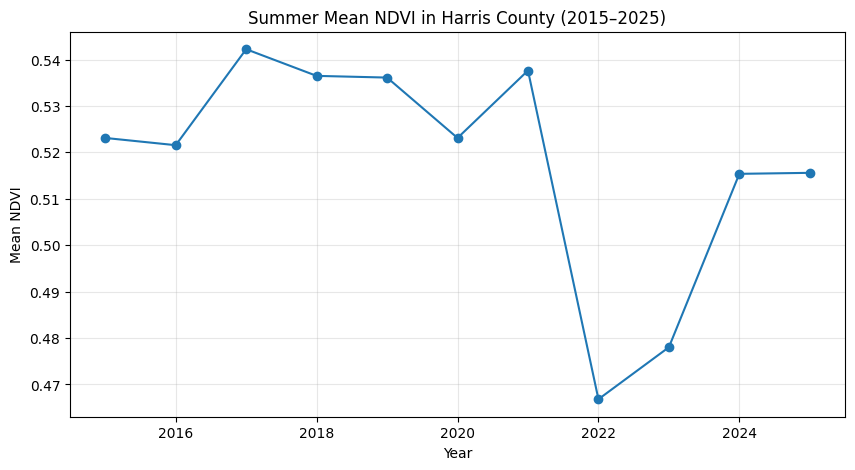

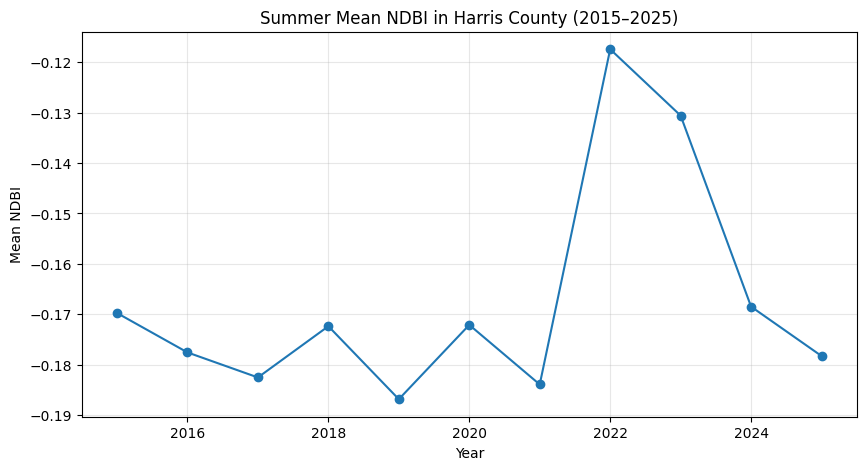

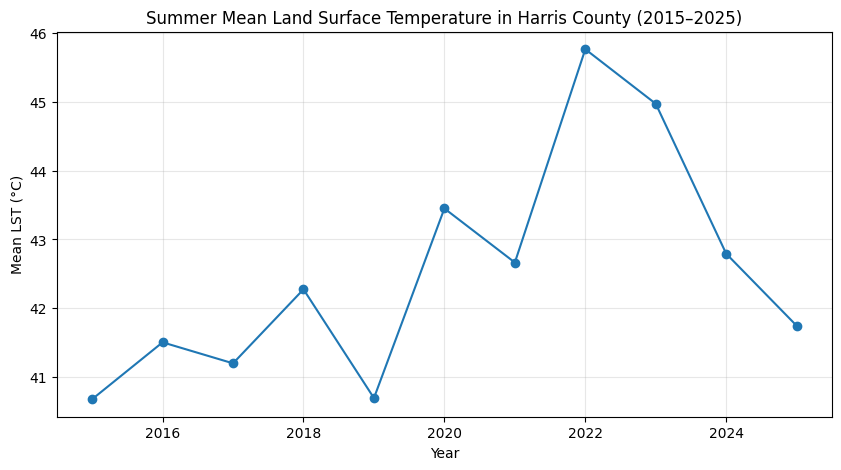

In [132]:
# Plot annual summer mean NDVI
plt.figure(figsize=(10, 5))

plt.plot(
    df['Year'],
    df['NDVI'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Mean NDVI')
plt.title('Summer Mean NDVI in Harris County (2015–2025)')
plt.grid(alpha=0.3)
plt.show()


# Plot annual summer mean NDBI
plt.figure(figsize=(10, 5))

plt.plot(
    df['Year'],
    df['NDBI'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Mean NDBI')
plt.title('Summer Mean NDBI in Harris County (2015–2025)')
plt.grid(alpha=0.3)
plt.show()


# Plot annual summer mean land surface temperature
plt.figure(figsize=(10, 5))

plt.plot(
    df['Year'],
    df['LST_C'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Mean LST (°C)')
plt.title('Summer Mean Land Surface Temperature in Harris County (2015–2025)')
plt.grid(alpha=0.3)
plt.show()

## 7. Trend Analysis

I performed linear regression to examine the direction and strength of change in annual summer NDVI, NDBI, and land surface temperature from 2015 to 2025.

For each variable, the analysis reports:

- **Slope:** estimated annual rate and direction of change.
- **R²:** proportion of the year-to-year variation explained by the linear trend.
- **p-value:** statistical evidence for a non-zero linear trend.



In [133]:
# Fit linear trends to the annual mean values
ndvi_trend = linregress(df['Year'], df['NDVI'])
ndbi_trend = linregress(df['Year'], df['NDBI'])
lst_trend = linregress(df['Year'], df['LST_C'])

# Report the slope, coefficient of determination (R²), and p-value
print(
    f"NDVI: slope = {ndvi_trend.slope:.4f}/year, "
    f"R² = {ndvi_trend.rvalue**2:.3f}, "
    f"p = {ndvi_trend.pvalue:.3f}"
)

print(
    f"NDBI: slope = {ndbi_trend.slope:.4f}/year, "
    f"R² = {ndbi_trend.rvalue**2:.3f}, "
    f"p = {ndbi_trend.pvalue:.3f}"
)

print(
    f"LST: slope = {lst_trend.slope:.3f} °C/year, "
    f"R² = {lst_trend.rvalue**2:.3f}, "
    f"p = {lst_trend.pvalue:.3f}"
)

NDVI: slope = -0.0036/year, R² = 0.236, p = 0.130
NDBI: slope = 0.0024/year, R² = 0.125, p = 0.286
LST: slope = 0.280 °C/year, R² = 0.311, p = 0.075


## 8. Relationship with Land Surface Temperature

I used Pearson correlation to examine the association between annual summer mean land surface temperature and the two spectral indices.

The analysis compares:

- NDVI and LST
- NDBI and LST



In [134]:
# Calculate Pearson correlations between the annual indices and LST
ndvi_lst_r, ndvi_lst_p = pearsonr(
    df['NDVI'],
    df['LST_C']
)

ndbi_lst_r, ndbi_lst_p = pearsonr(
    df['NDBI'],
    df['LST_C']
)

# Report the correlation coefficients and p-values
print(
    f"NDVI vs LST: r = {ndvi_lst_r:.3f}, "
    f"p = {ndvi_lst_p:.4f}"
)

print(
    f"NDBI vs LST: r = {ndbi_lst_r:.3f}, "
    f"p = {ndbi_lst_p:.4f}"
)

NDVI vs LST: r = -0.834, p = 0.0014
NDBI vs LST: r = 0.874, p = 0.0004


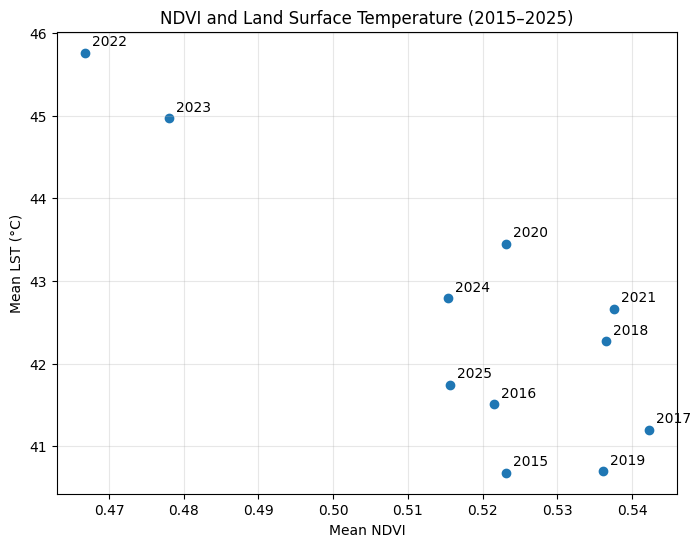

In [135]:
# Plot the relationship between annual mean NDVI and LST
plt.figure(figsize=(8, 6))

plt.scatter(
    df['NDVI'],
    df['LST_C']
)

# Label each observation with its corresponding year
for _, row in df.iterrows():
    plt.annotate(
        int(row['Year']),
        (row['NDVI'], row['LST_C']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Mean NDVI')
plt.ylabel('Mean LST (°C)')
plt.title('NDVI and Land Surface Temperature (2015–2025)')
plt.grid(alpha=0.3)

plt.show()

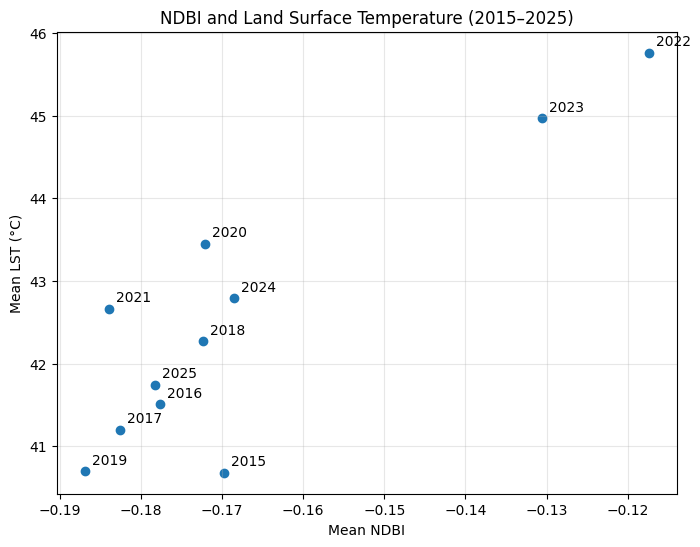

In [136]:
# Plot the relationship between annual mean NDBI and LST
plt.figure(figsize=(8, 6))

plt.scatter(
    df['NDBI'],
    df['LST_C']
)

# Label each observation with its corresponding year
for _, row in df.iterrows():
    plt.annotate(
        int(row['Year']),
        (row['NDBI'], row['LST_C']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Mean NDBI')
plt.ylabel('Mean LST (°C)')
plt.title('NDBI and Land Surface Temperature (2015–2025)')
plt.grid(alpha=0.3)

plt.show()

## 9. Findings
These are my findings:

The 2015–2025 summer time series shows year-to-year changes in vegetation, built-up surface characteristics, and land surface temperature across Harris County. NDVI had a negative trend of -0.0036 per year, suggesting a general decrease in vegetation greenness over the study period. However, this trend was not statistically significant (R² = 0.236, p = 0.130). NDBI had a positive trend of +0.0024 per year, suggesting a general increase in built-up and non-vegetated surface characteristics, but this trend was also not statistically significant (R² = 0.125, p = 0.286). Mean land surface temperature showed a positive trend of about +0.28 °C per year, although the trend was not statistically significant at the 0.05 level (R² = 0.311, p = 0.075).

The results also showed strong relationships between the spectral indices and land surface temperature. NDVI had a strong negative correlation with LST (r = -0.834, p = 0.0014), meaning that years with lower vegetation greenness generally had higher surface temperatures. NDBI had a strong positive correlation with LST (r = 0.874, p = 0.0004), meaning that years with higher NDBI values generally had higher surface temperatures.

